# Housing Market Simulation

This notebook runs a discrete-event housing market simulation and reconstructs
all analytics exclusively from the **event log**. Nine renters with modest
incomes compete for five houses; most cannot sustain rent indefinitely, so
eviction and re-bidding cycles dominate the dynamics.

In [1]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../..").resolve()))
os.environ["DISABLE_PANDERA_IMPORT_WARNING"] = "True"

from core import (
    Agent,
    AgentIncomeReceived,
    AuctionClear,
    CompositeAgentPolicy,
    EventFact,
    EventQueue,
    HomelessBiddingPolicy,
    House,
    HousingMarket,
    IncomePolicy,
    OccupancyLog,
    SignalRegistry,
    SimulationEngine,
    SimulationSettings,
    VacantState,
    WealthLog,
    build_fact_table,
    plot_avg_rent,
    plot_house_rents,
    plot_housed_renter_wealth,
    plot_occupancy,
    plot_paid_vs_asked,
    plot_renter_wealth,
    plot_time_to_rent,
    plot_vacancy,
    project_asking_rent,
    project_occupancy,
    project_rent_payments,
    project_time_to_rent,
    project_vacancy_count,
    project_wealth,
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")

## Market Setup

- **Landlord** owns all five houses and earns no external income (lives off rent).
- Nine renters (**Alice -- Ivy**) have modest incomes that, for most agents,
  fall short of covering rent. Each uses a composite policy that collects income
  and bids on vacant houses when homeless.
- Rent is paid every period; tenants who cannot pay are evicted. With four
  agents always homeless, competition for vacancies is constant.

In [2]:
settings = SimulationSettings(vacancy_decay_rate=0.005)

owner_policy = IncomePolicy()
renter_policy = CompositeAgentPolicy(
    policies=(IncomePolicy(), HomelessBiddingPolicy())
)

landlord = Agent(
    id="landlord", money=100, income=0, spend_rate=0.0, policy=owner_policy,
)

renter_specs = [
    # (id,       money, income, spend_rate)
    ("alice",    10,     8,     0.60),
    ("bob",       5,     6,     0.70),
    ("carol",     8,     7,     0.65),
    ("dave",      7,     6,     0.60),
    ("eve",       4,     5,     0.75),
    ("frank",     9,     7,     0.62),
    ("grace",     3,     4,     0.80),
    ("hank",      6,     6,     0.68),
    ("ivy",       8,     7,     0.62),
]
renters = tuple(
    Agent(id=name, money=money, income=inc, spend_rate=sr, policy=renter_policy)
    for name, money, inc, sr in renter_specs
)

house_specs = [
    # (id,        rent, age)
    ("house_a",  10.0,  10),
    ("house_b",  15.0,   7),
    ("house_c",  20.0,   5),
    ("house_d",  25.0,   3),
    ("house_e",  35.0,   1),
]
houses = tuple(
    House(id=hid, owner_id="landlord", state=VacantState(), rent_price=rent, age=age)
    for hid, rent, age in house_specs
)

market = HousingMarket(
    entities=(landlord,) + renters + houses,
    settings=settings,
)

queue = EventQueue()
for agent in market.agents:
    queue = queue.push(AgentIncomeReceived(time=0, agent_id=agent.id))
queue = queue.push(AuctionClear(time=0))

engine = SimulationEngine(
    market=market, queue=queue, registry=SignalRegistry()
)

In [3]:
N_STEPS = 150_000
MAX_T = 800
sim = engine

for _ in range(N_STEPS):
    if not sim.queue.events:
        break
    sim = sim.step()
    if sim.now >= MAX_T:
        break

event_log = list(sim.event_log)
print(f"Processed {len(event_log)} events, simulation time reached t={sim.now}")

Processed 62956 events, simulation time reached t=800.0


## Analytics Layer

All downstream analysis is derived exclusively from the `event_log`.
We first materialise a single **fact table** (one row per event, warehouse-style)
validated by a pandera schema. Every visualisation is then a query against that
table -- no code ever touches the raw event objects again after the initial ETL.

In [4]:
facts = build_fact_table(event_log, market)

wealth_df = project_wealth(facts, market)
occupancy_df = project_occupancy(facts, market)
rent_df = project_rent_payments(facts)
vacancy_df = project_vacancy_count(occupancy_df)
ttr_df = project_time_to_rent(facts, market)
asking_rent_df = project_asking_rent(facts, occupancy_df, market)

In [5]:
print(f"Fact table:    {len(facts):>5} rows  |  {facts[EventFact.event_type].value_counts().to_dict()}")
print()
print(f"Wealth log:    {len(wealth_df):>5} rows  |  {wealth_df[WealthLog.time].nunique()} unique times")
print(f"Occupancy log: {len(occupancy_df):>5} rows  |  {occupancy_df[OccupancyLog.time].nunique()} unique times")
print(f"Rent payments: {len(rent_df):>5} rows")
print(f"Vacancy count: {len(vacancy_df):>5} rows")
print(f"Time-to-rent:  {len(ttr_df):>5} rows")
print(f"Asking rent:   {len(asking_rent_df):>5} rows")

Fact table:    60461 rows  |  {'bid': 41189, 'income': 8001, 'auction_clear': 8001, 'rent_collected': 1722, 'rent_started': 775, 'evicted': 773}

Wealth log:     8010 rows  |  801 unique times
Occupancy log:  4005 rows  |  801 unique times
Rent payments:  1722 rows
Vacancy count:   801 rows
Time-to-rent:    775 rows
Asking rent:    4005 rows


## Visualizations

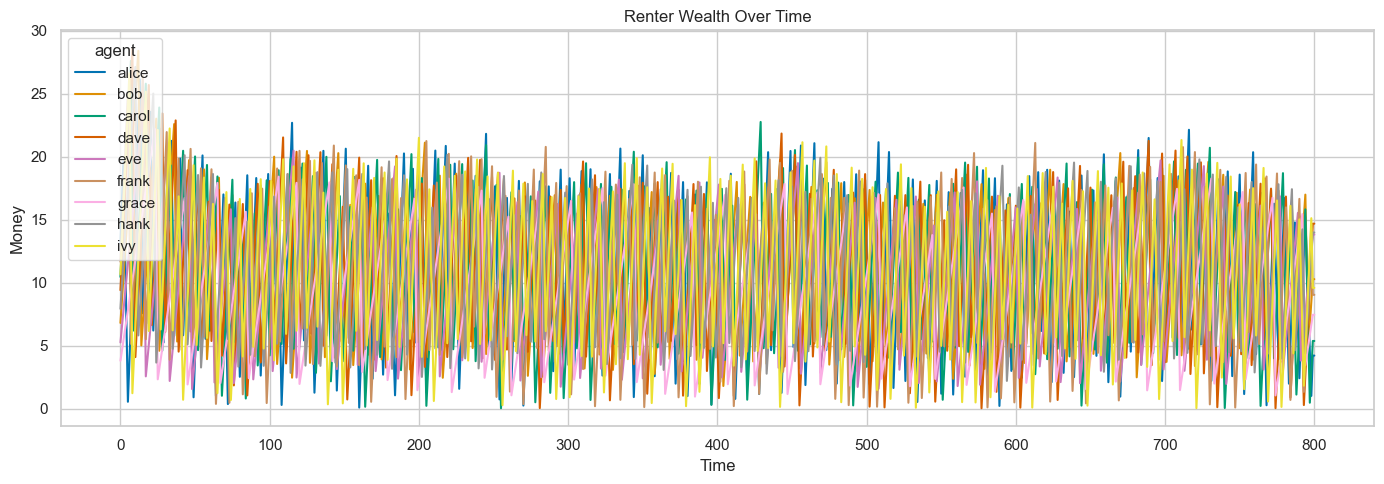

In [6]:
plot_renter_wealth(wealth_df)
plt.show()

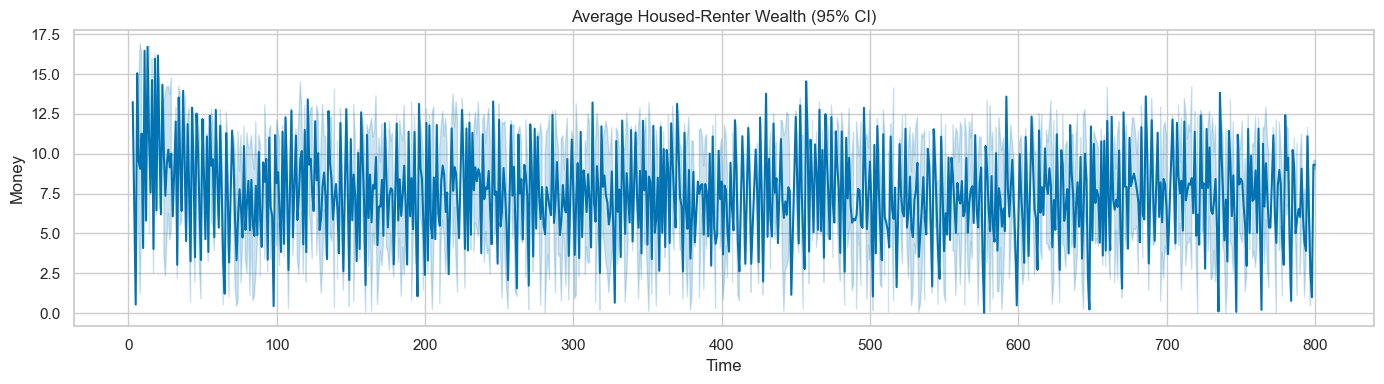

In [7]:
plot_housed_renter_wealth(wealth_df, occupancy_df)
plt.show()

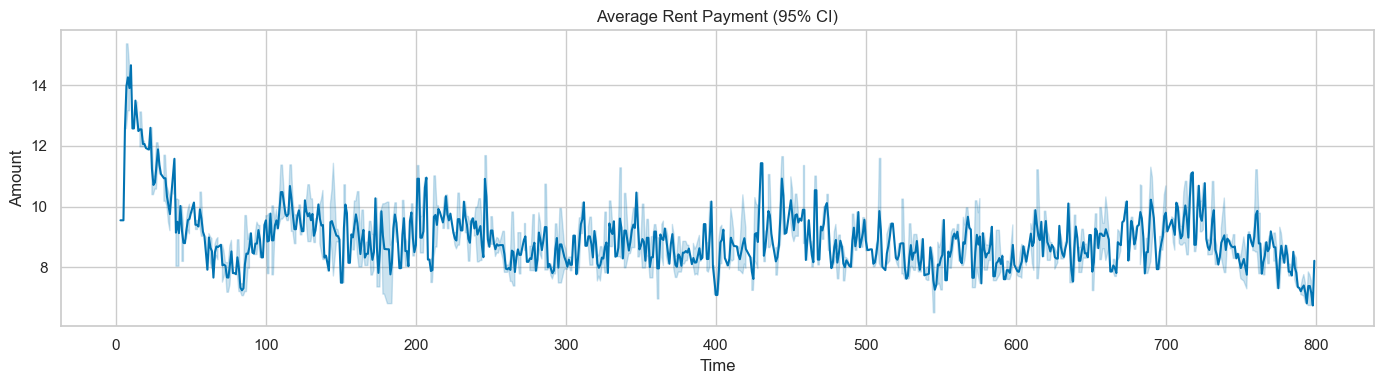

In [8]:
plot_avg_rent(rent_df)
plt.show()

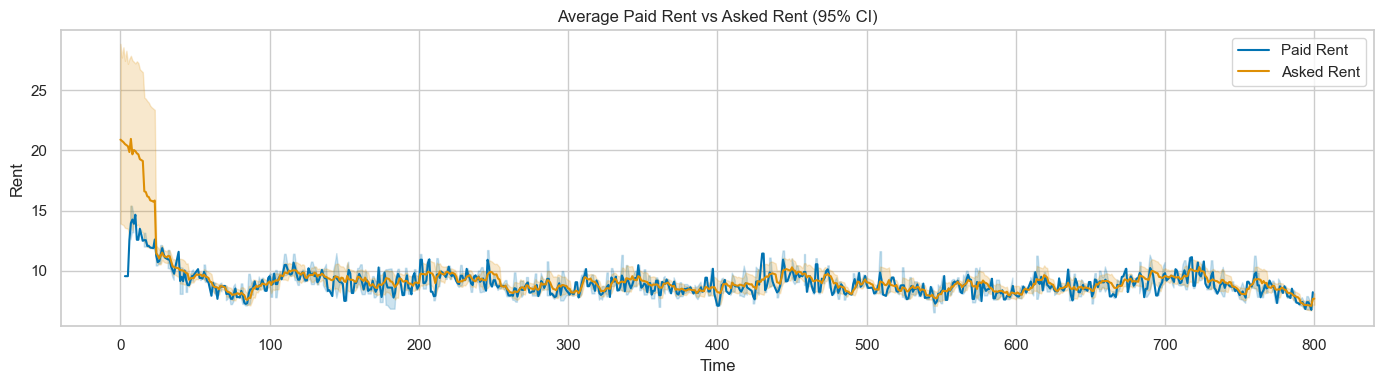

In [9]:
plot_paid_vs_asked(rent_df, asking_rent_df)
plt.show()

In [ ]:
plot_house_rents(asking_rent_df)
plt.show()

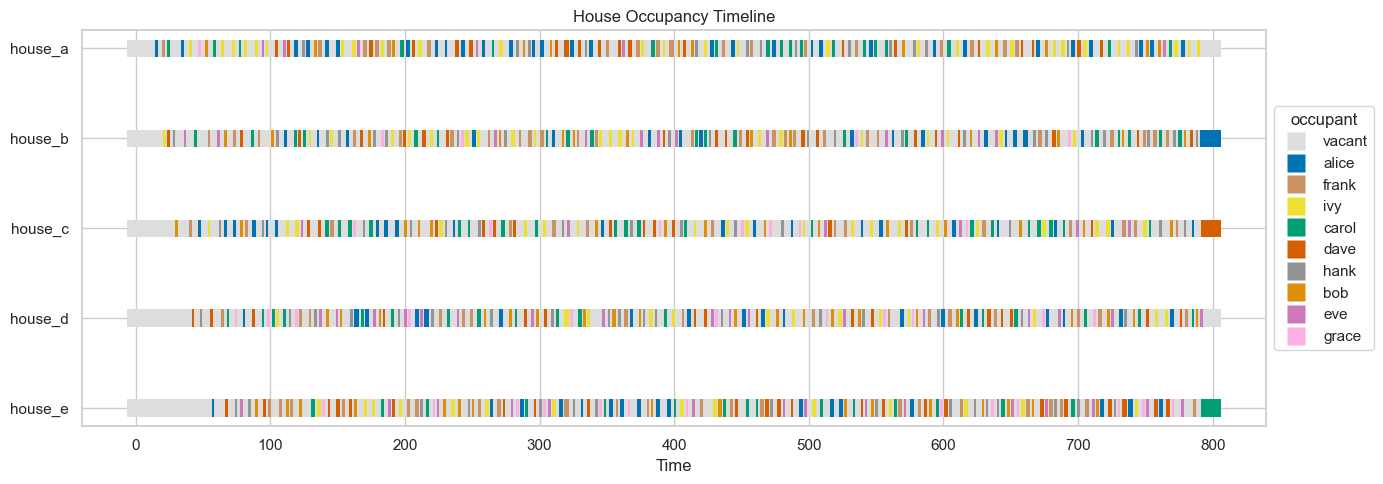

In [ ]:
plot_occupancy(occupancy_df)
plt.show()

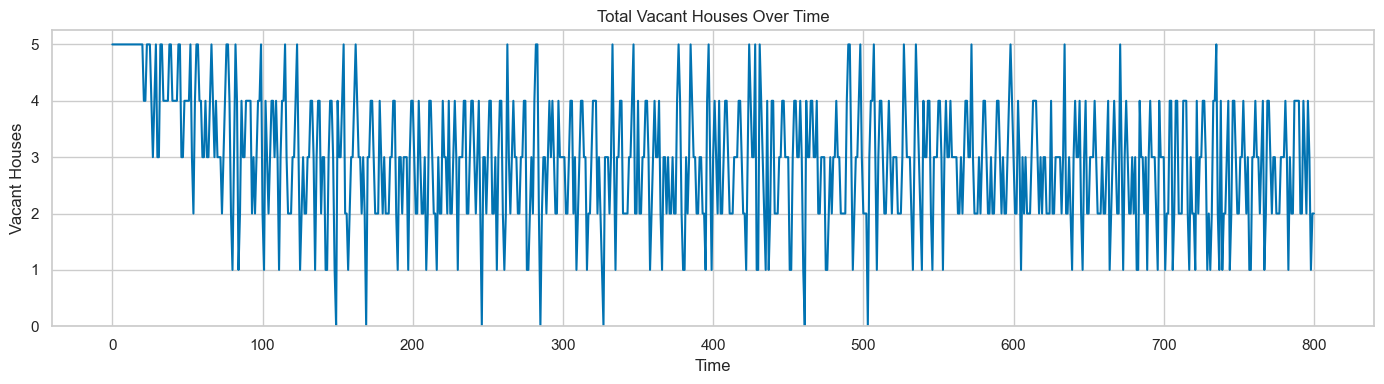

In [ ]:
plot_vacancy(vacancy_df)
plt.show()

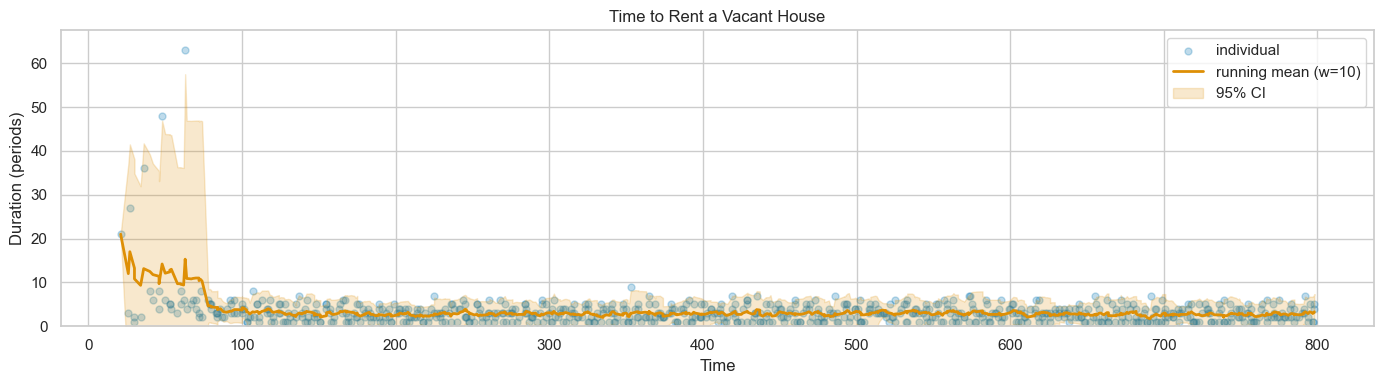

In [ ]:
plot_time_to_rent(ttr_df)
plt.show()